# Cycle 3 Question 8: SadOrHopeless and Current Cigarette Use

This notebook loads the YRBS 2007 dataset, recodes the variables, creates descriptive summaries, runs a two-proportion z-test, and saves final tables and figures.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from scipy.stats import norm
from pathlib import Path

ROOT = Path('..')
RAW_PATH = ROOT / 'data' / 'raw' / 'YRBS_2007.csv'
FIG_DIR = ROOT / 'outputs' / 'figures'
TABLE_DIR = ROOT / 'outputs' / 'tables'
SUMMARY_DIR = ROOT / 'outputs' / 'summary'

for p in [FIG_DIR, TABLE_DIR, SUMMARY_DIR]:
    p.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RAW_PATH)
df.shape

(14041, 103)

## Recoding

- `SadOrHopeless`: 1 = yes, 0 = no.
- `CurrentCigaretteUse`: 1 = codes 2-7, 0 = code 1.

In [2]:
sad = df['SadOrHopeless'].map({1.0: 1, 2.0: 0})
cig = df['CurrentCigaretteUse'].apply(lambda x: 0 if x == 1 else (1 if x in [2,3,4,5,6,7] else np.nan))

analysis = pd.DataFrame({
    'sad_or_hopeless_binary': sad,
    'current_cigarette_binary': cig
}).dropna().astype(int)

analysis['sad_group_label'] = analysis['sad_or_hopeless_binary'].map({1:'SadOrHopeless = Yes',0:'SadOrHopeless = No'})
analysis['current_cigarette_label'] = analysis['current_cigarette_binary'].map({1:'Current cigarette use',0:'No current cigarette use'})
analysis.to_csv(ROOT / 'data' / 'processed' / 'yrbs_2007_cycle3_q8_cleaned.csv', index=False)
analysis.head()

,sad_or_hopeless_binary,current_cigarette_binary,sad_group_label,current_cigarette_label
0,1,1,SadOrHopeless = Yes,Current cigarette use
3,1,0,SadOrHopeless = Yes,No current cigarette use
4,1,0,SadOrHopeless = Yes,No current cigarette use
5,0,0,SadOrHopeless = No,No current cigarette use
6,0,0,SadOrHopeless = No,No current cigarette use


## Data Check

In [3]:
data_check = pd.DataFrame({
    'item':['Raw rows','Valid SadOrHopeless rows','Missing/invalid SadOrHopeless rows','Valid CurrentCigaretteUse rows','Missing/invalid CurrentCigaretteUse rows','Rows valid for both variables'],
    'count':[len(df), int(sad.notna().sum()), int(sad.isna().sum()), int(cig.notna().sum()), int(cig.isna().sum()), len(analysis)]
})
data_check.to_csv(TABLE_DIR / 'data_check.csv', index=False)
data_check

,item,count
0,Raw rows,14041
1,Valid SadOrHopeless rows,13845
2,Missing/invalid SadOrHopeless rows,196
3,Valid CurrentCigaretteUse rows,13323
4,Missing/invalid CurrentCigaretteUse rows,718
5,Rows valid for both variables,13174


## Group Summary

In [4]:
summary = (analysis.groupby('sad_or_hopeless_binary')['current_cigarette_binary']
           .agg(sample_size='count', current_cigarette_users='sum', proportion='mean')
           .reset_index())
summary['group'] = summary['sad_or_hopeless_binary'].map({1:'Felt sad or hopeless',0:'Did not feel sad or hopeless'})
summary = summary[['group','sample_size','current_cigarette_users','proportion']]
summary['order'] = summary['group'].map({'Felt sad or hopeless':0,'Did not feel sad or hopeless':1})
summary = summary.sort_values('order').drop(columns='order')
summary['proportion_percent'] = summary['proportion'] * 100
summary.to_csv(TABLE_DIR / 'group_summary.csv', index=False)
summary

,group,sample_size,current_cigarette_users,proportion,proportion_percent
1,Felt sad or hopeless,3854,1064,0.276077,27.607680
0,Did not feel sad or hopeless,9320,1508,0.161803,16.180258


## Two-Proportion z-Test and Confidence Interval

In [5]:
g1 = summary.iloc[0]
g0 = summary.iloc[1]
n1, x1, p1 = int(g1.sample_size), int(g1.current_cigarette_users), float(g1.proportion)
n0, x0, p0 = int(g0.sample_size), int(g0.current_cigarette_users), float(g0.proportion)

diff = p1 - p0
se_unpooled = sqrt(p1*(1-p1)/n1 + p0*(1-p0)/n0)
ci_low = diff - 1.96 * se_unpooled
ci_high = diff + 1.96 * se_unpooled

pooled = (x1 + x0) / (n1 + n0)
se_pooled = sqrt(pooled * (1-pooled) * (1/n1 + 1/n0))
z_stat = diff / se_pooled
p_value = 2 * norm.sf(abs(z_stat))

inference = pd.DataFrame({
    'measure':[ 'p_yes', 'p_no', 'difference_p_yes_minus_p_no', 'ci_low_95', 'ci_high_95', 'z_statistic', 'p_value', 'alpha', 'decision'],
    'value':[p1, p0, diff, ci_low, ci_high, z_stat, p_value, 0.05, 'Reject H0' if p_value < 0.05 else 'Fail to reject H0']
})
inference.to_csv(TABLE_DIR / 'inference_summary.csv', index=False)
inference

,measure,value
0,p_yes,0.276077
1,p_no,0.161803
2,difference_p_yes_minus_p_no,0.114274
3,ci_low_95,0.098302
4,ci_high_95,0.130247
5,z_statistic,15.053641
6,p_value,0.0
7,alpha,0.05
8,decision,Reject H0


## Visualizations

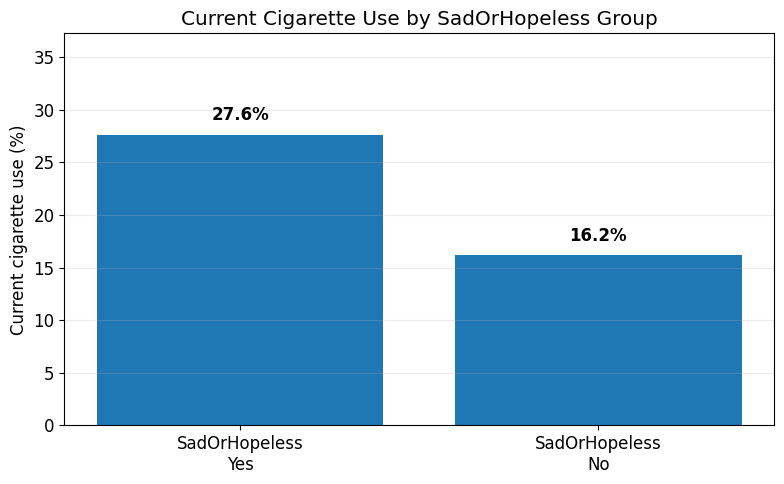

In [6]:
plt.rcParams.update({'font.size': 12})
labels = ['SadOrHopeless\nYes','SadOrHopeless\nNo']
vals = [p1*100, p0*100]

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(labels, vals)
ax.set_ylabel('Current cigarette use (%)')
ax.set_title('Current Cigarette Use by SadOrHopeless Group')
ax.set_ylim(0, max(vals)*1.35)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / 'proportion_bar_chart.png', dpi=200)
plt.show()

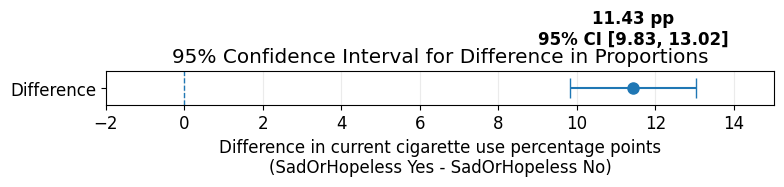

In [7]:
fig, ax = plt.subplots(figsize=(8,3.8))
ax.errorbar([diff*100], [0], xerr=[[(diff-ci_low)*100], [(ci_high-diff)*100]], fmt='o', capsize=7, markersize=8)
ax.axvline(0, linestyle='--', linewidth=1)
ax.set_yticks([0])
ax.set_yticklabels(['Difference'])
ax.set_xlabel('Difference in current cigarette use percentage points\n(SadOrHopeless Yes - SadOrHopeless No)')
ax.set_title('95% Confidence Interval for Difference in Proportions')
ax.set_xlim(min(ci_low*100 - 2, -2), ci_high*100 + 2)
ax.text(diff*100, 0.13, f'{diff*100:.2f} pp\n95% CI [{ci_low*100:.2f}, {ci_high*100:.2f}]', ha='center', va='bottom', fontweight='bold')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / 'difference_ci_plot.png', dpi=200)
plt.show()

## Final Interpretation

In [8]:
p_display = '< 0.0001' if p_value < 0.0001 else f'{p_value:.4f}'
final_interpretation = f'''The proportion of current cigarette use was higher among students who felt sad or hopeless ({p1*100:.1f}%) than among students who did not feel sad or hopeless ({p0*100:.1f}%). The estimated difference was {diff*100:.2f} percentage points. The 95% CI was [{ci_low*100:.2f}, {ci_high*100:.2f}] percentage points. Since the p-value was {p_display}, we reject H0 at alpha = 0.05. This suggests a statistically significant association between SadOrHopeless status and current cigarette use, but it does not prove causation.'''
(SUMMARY_DIR / 'final_interpretation.txt').write_text(final_interpretation, encoding='utf-8')
print(final_interpretation)

The proportion of current cigarette use was higher among students who felt sad or hopeless (27.6%) than among students who did not feel sad or hopeless (16.2%). The estimated difference was 11.43 percentage points. The 95% CI was [9.83, 13.02] percentage points. Since the p-value was < 0.0001, we reject H0 at alpha = 0.05. This suggests a statistically significant association between SadOrHopeless status and current cigarette use, but it does not prove causation.
